# RQ6: Technology Admiration vs. Adoption Gap Analysis

**Research Question:** Which programming languages exhibit the largest gap between admiration rates and current adoption rates across the developer population — and how does this admiration–adoption gap vary across developer role categories, and can the relationship between admiration and adoption be modeled with polynomial regression?

**Task:** Technology Trend Analysis + Polynomial Regression  
**Columns:** `LanguageHaveWorkedWith`, `LanguageAdmired`, `LanguageWantToWorkWith`  
**Dataset:** Stack Overflow Annual Developer Survey 2025

In [91]:
import os
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score

warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
PALETTE = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0', '#FF9800', '#00BCD4', '#795548']
sns.set_palette(PALETTE)
RANDOM_STATE = 42
OUTPUT_DIR = '/kaggle/working/'

def save_figure(fig, filename):
    path = os.path.join(OUTPUT_DIR, filename)
    fig.savefig(path, format='pdf', bbox_inches='tight', dpi=300)
    plt.show()
    plt.close(fig)
    print(f'Saved figure: {path}')

def save_table(df, filename):
    path = os.path.join(OUTPUT_DIR, filename)
    df.to_csv(path, index=False)
    print(f'Saved table:  {path}')

DEVTYPE_GROUP_MAP = {
    'Developer, full-stack':                         'Full-Stack',
    'Developer, back-end':                           'Backend',
    'Developer, front-end':                          'Frontend',
    'Developer, mobile':                             'Mobile',
    'Developer, embedded applications or devices':   'Embedded',
    'Data scientist':                                'Data/AI',
    'AI/ML engineer':                                'Data/AI',
    'Data engineer':                                 'Data/AI',
    'DevOps engineer or professional':               'DevOps',
    'Architect, software or solutions':              'Architect'
}

def devtype_first_match(devtype_str):
    if not isinstance(devtype_str, str) or devtype_str == 'NA':
        return None
    roles = [r.strip() for r in devtype_str.split(';')]
    for role in roles:
        if role in DEVTYPE_GROUP_MAP:
            return DEVTYPE_GROUP_MAP[role]
    return None

def compute_rates(series, col_name):
    answered = series.notna() & (series != 'NA')
    n_answered = answered.sum()
    all_vals = []
    for v in series[answered]:
        all_vals.extend([x.strip() for x in v.split(';')])
    counts = Counter(all_vals)
    return counts, n_answered

def fit_poly(x, y, degree):
    pipe = Pipeline([
        ('poly', PolynomialFeatures(degree=degree, include_bias=True)),
        ('lr',   LinearRegression())
    ])
    X = np.array(x).reshape(-1, 1)
    pipe.fit(X, y)
    y_pred = pipe.predict(X)
    r2 = r2_score(y, y_pred)
    return pipe, r2

print('Imports OK')

Imports OK


## 1. Data Loading

In [92]:
import glob
matches = glob.glob('/kaggle/input/**/survey_results_public.csv', recursive=True)
if not matches:
    raise FileNotFoundError('survey_results_public.csv not found under /kaggle/input/')
FILE_PATH = matches[0]
print('Using:', FILE_PATH)

df = pd.read_csv(FILE_PATH, encoding='utf-8-sig')
print(f'Shape: {df.shape}')

Using: /kaggle/input/datasets/edoardogalli/stack-overflow-annual-developer-survey-2025/survey_results_public.csv
Shape: (49123, 170)


## 2. Compute Admiration, Adoption, and Want Rates

In [93]:
have_counts, n_have = compute_rates(df['LanguageHaveWorkedWith'], 'have')
adm_counts,  n_adm  = compute_rates(df['LanguageAdmired'],         'admired')
want_counts, n_want = compute_rates(df['LanguageWantToWorkWith'],  'want')

print(f'n (HaveWorkedWith): {n_have}')
print(f'n (Admired):        {n_adm}')
print(f'n (WantToWorkWith): {n_want}')

# Union of all languages
all_langs = set(have_counts) | set(adm_counts) | set(want_counts)

rate_rows = []
for lang in all_langs:
    adoption   = have_counts.get(lang, 0) / n_have
    admiration = adm_counts.get(lang, 0)  / n_adm
    want       = want_counts.get(lang, 0) / n_want
    if adoption > 0.01:  # filter noise
        rate_rows.append({
            'Language':      lang,
            'Adoption_Rate':   round(adoption, 5),
            'Admiration_Rate': round(admiration, 5),
            'Want_Rate':       round(want, 5),
            'Gap_Score':       round(admiration - adoption, 5),
            'N_Adopted':  have_counts.get(lang, 0),
            'N_Admired':  adm_counts.get(lang, 0),
            'N_Want':     want_counts.get(lang, 0)
        })

rates_df = pd.DataFrame(rate_rows).sort_values('Gap_Score', ascending=False).reset_index(drop=True)
rates_df['Rank_by_Gap'] = rates_df['Gap_Score'].rank(ascending=False).astype(int)
print(f'Languages with adoption > 1%: {len(rates_df)}')
rates_df.head(10)

n (HaveWorkedWith): 31643
n (Admired):        23447
n (WantToWorkWith): 27054
Languages with adoption > 1%: 40


,Language,Adoption_Rate,Admiration_Rate,Want_Rate,Gap_Score,N_Adopted,N_Admired,N_Want,Rank_by_Gap
0,Gleam,0.01116,0.01066,0.03585,-0.00049,353,250,970,1
1,Zig,0.02143,0.01855,0.08908,-0.00287,678,435,2410,2
2,Elixir,0.02677,0.02380,0.06713,-0.00297,847,558,1816,3
3,Rust,0.14907,0.14569,0.34191,-0.00338,4717,3416,9250,4
4,OCaml,0.01160,0.00806,0.03190,-0.00354,367,189,863,5
5,F#,0.01283,0.00853,0.03356,-0.00430,406,200,908,6
6,Erlang,0.01470,0.00994,0.03530,-0.00476,465,233,955,7
7,Lisp,0.02373,0.01855,0.04192,-0.00518,751,435,1134,8
8,Prolog,0.01065,0.00469,0.01527,-0.00596,337,110,413,9
9,Ada,0.01362,0.00759,0.01889,-0.00603,431,178,511,10


## 3. Polynomial Regression: Admiration vs Adoption

In [94]:
x = rates_df['Adoption_Rate'].values
y = rates_df['Admiration_Rate'].values

poly2_pipe, r2_poly2 = fit_poly(x, y, degree=2)
poly3_pipe, r2_poly3 = fit_poly(x, y, degree=3)

rates_df['Poly2_R2'] = round(r2_poly2, 4)
rates_df['Poly3_R2'] = round(r2_poly3, 4)

print(f'Polynomial Degree 2 R²: {r2_poly2:.4f}')
print(f'Polynomial Degree 3 R²: {r2_poly3:.4f}')

Polynomial Degree 2 R²: 0.9807
Polynomial Degree 3 R²: 0.9846


## 4. Gap by DevType Group

In [95]:
df['DevType_Group'] = df['DevType'].apply(devtype_first_match)
DEVTYPE_GROUPS = ['Full-Stack', 'Backend', 'Frontend', 'Mobile', 'Embedded', 'Data/AI', 'DevOps', 'Architect']

top15_langs = rates_df.nlargest(15, 'Adoption_Rate')['Language'].tolist()

gap_by_dt_rows = []
for lang in top15_langs:
    for dt_grp in DEVTYPE_GROUPS:
        sub = df[df['DevType_Group'] == dt_grp]
        n_dt = len(sub)
        if n_dt < 20:
            continue
        answered_have = sub['LanguageHaveWorkedWith'].notna() & (sub['LanguageHaveWorkedWith'] != 'NA')
        answered_adm  = sub['LanguageAdmired'].notna()         & (sub['LanguageAdmired']         != 'NA')
        n_have_dt = answered_have.sum()
        n_adm_dt  = answered_adm.sum()
        adop_dt = sub[answered_have]['LanguageHaveWorkedWith'].apply(
            lambda x: 1 if lang in x.split(';') else 0).sum() / n_have_dt if n_have_dt > 0 else 0
        adm_dt  = sub[answered_adm]['LanguageAdmired'].apply(
            lambda x: 1 if lang in x.split(';') else 0).sum() / n_adm_dt  if n_adm_dt  > 0 else 0
        gap_by_dt_rows.append({
            'Language':       lang,
            'DevType_Group':  dt_grp,
            'Adoption_Rate':  round(adop_dt, 5),
            'Admiration_Rate': round(adm_dt, 5),
            'Gap_Score':      round(adm_dt - adop_dt, 5),
            'N_respondents':  n_dt
        })

gap_dt_df = pd.DataFrame(gap_by_dt_rows)
save_table(gap_dt_df, 'rq6_gap_by_devtype.csv')
print(f'Gap-by-DevType table: {gap_dt_df.shape}')

Saved table:  /kaggle/working/rq6_gap_by_devtype.csv
Gap-by-DevType table: (120, 6)


## 5. Publication-Ready Figures

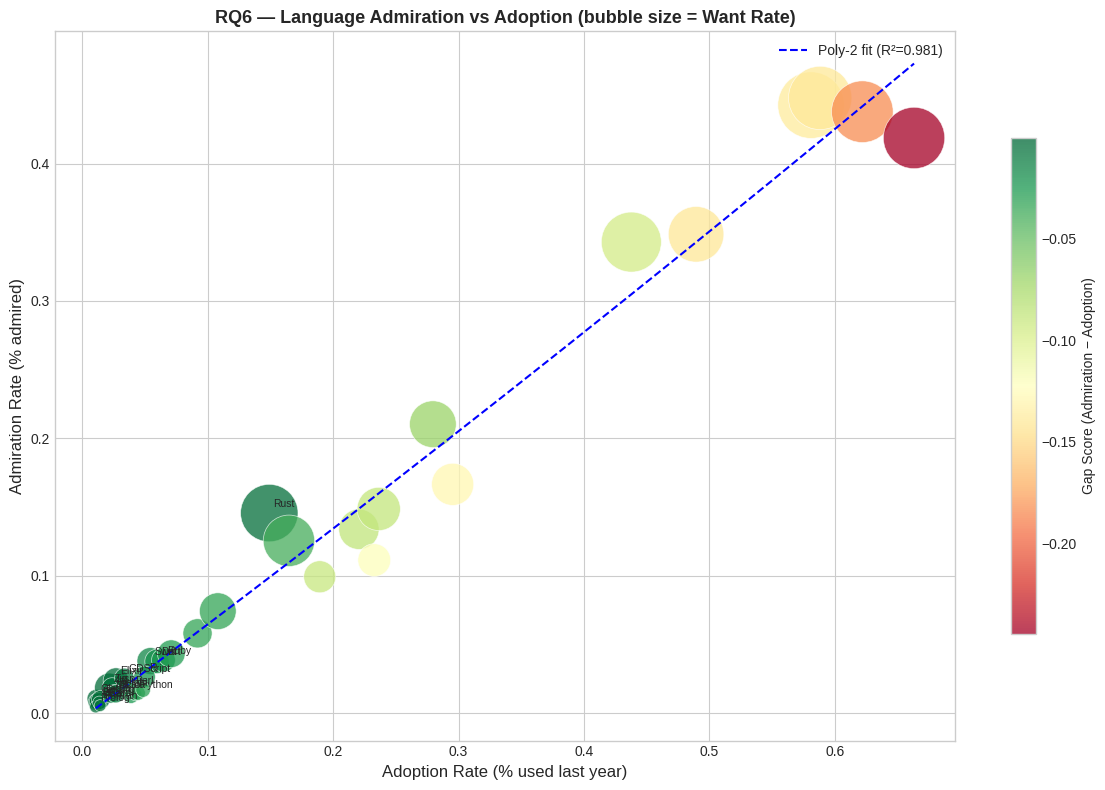

Saved figure: /kaggle/working/rq6_admiration_adoption_bubble.pdf


In [96]:
# Bubble chart: admiration vs adoption
top20 = rates_df.head(20)

gap_min = rates_df['Gap_Score'].min()
gap_max = rates_df['Gap_Score'].max()

# TwoSlopeNorm requires vmin < 0 < vmax; fall back if data is all one side
if gap_min < 0 < gap_max:
    norm = mcolors.TwoSlopeNorm(vmin=gap_min, vcenter=0, vmax=gap_max)
else:
    norm = mcolors.Normalize(vmin=gap_min, vmax=gap_max)

cmap = plt.cm.RdYlGn

fig, ax = plt.subplots(figsize=(12, 8))

sc = ax.scatter(
    rates_df['Adoption_Rate'],
    rates_df['Admiration_Rate'],
    s=rates_df['Want_Rate'] * 5000,
    c=rates_df['Gap_Score'],
    cmap=cmap, norm=norm,
    alpha=0.75, edgecolors='white', linewidths=0.5
)

# Label top 20 by adoption
for _, row in top20.iterrows():
    ax.annotate(row['Language'],
                (row['Adoption_Rate'], row['Admiration_Rate']),
                fontsize=7.5, ha='left', va='bottom',
                xytext=(3, 3), textcoords='offset points')

# Polynomial regression line
x_line = np.linspace(rates_df['Adoption_Rate'].min(), rates_df['Adoption_Rate'].max(), 200)
y_line = poly2_pipe.predict(x_line.reshape(-1, 1))
ax.plot(x_line, y_line, 'b--', linewidth=1.5, label=f'Poly-2 fit (R²={r2_poly2:.3f})')

ax.set_xlabel('Adoption Rate (% used last year)', fontsize=12)
ax.set_ylabel('Admiration Rate (% admired)', fontsize=12)
ax.set_title('RQ6 — Language Admiration vs Adoption (bubble size = Want Rate)', fontsize=13, fontweight='bold')
cbar = plt.colorbar(sc, ax=ax, shrink=0.7)
cbar.set_label('Gap Score (Admiration − Adoption)', fontsize=10)
ax.legend(fontsize=10)
plt.tight_layout()
save_figure(fig, 'rq6_admiration_adoption_bubble.pdf')
plt.show()

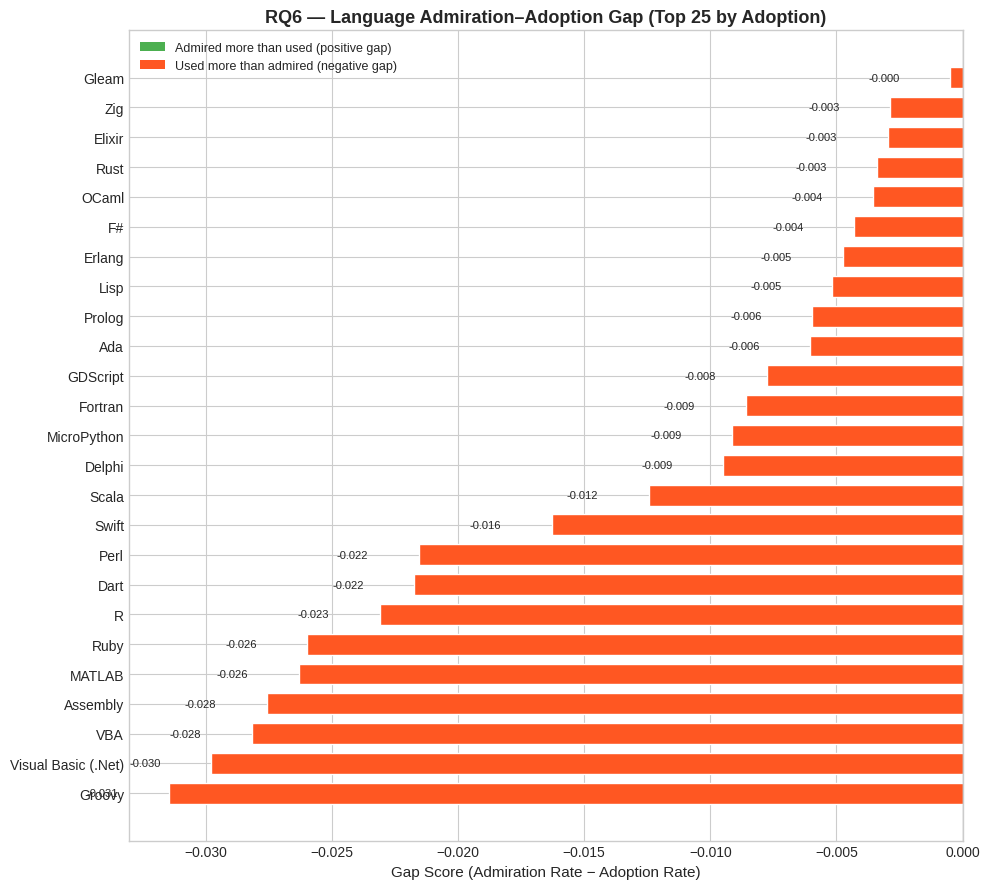

Saved figure: /kaggle/working/rq6_gap_score_bar.pdf


In [97]:
# Gap score horizontal bar chart
top25 = rates_df.head(25)
colors_bar = [PALETTE[2] if v >= 0 else PALETTE[1] for v in top25['Gap_Score']]

fig, ax = plt.subplots(figsize=(10, 9))
bars = ax.barh(top25['Language'], top25['Gap_Score'], color=colors_bar, edgecolor='white', height=0.7)
ax.axvline(0, color='black', linewidth=0.8)
for bar, val in zip(bars, top25['Gap_Score']):
    ax.text(val + (0.002 if val >= 0 else -0.002), bar.get_y() + bar.get_height() / 2,
            f'{val:+.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=8)
ax.set_xlabel('Gap Score (Admiration Rate − Adoption Rate)', fontsize=11)
ax.set_title('RQ6 — Language Admiration–Adoption Gap (Top 25 by Adoption)', fontsize=13, fontweight='bold')

from matplotlib.patches import Patch
legend_elems = [Patch(facecolor=PALETTE[2], label='Admired more than used (positive gap)'),
                Patch(facecolor=PALETTE[1], label='Used more than admired (negative gap)')]
ax.legend(handles=legend_elems, fontsize=9)
plt.gca().invert_yaxis()
plt.tight_layout()
save_figure(fig, 'rq6_gap_score_bar.pdf')
plt.show()

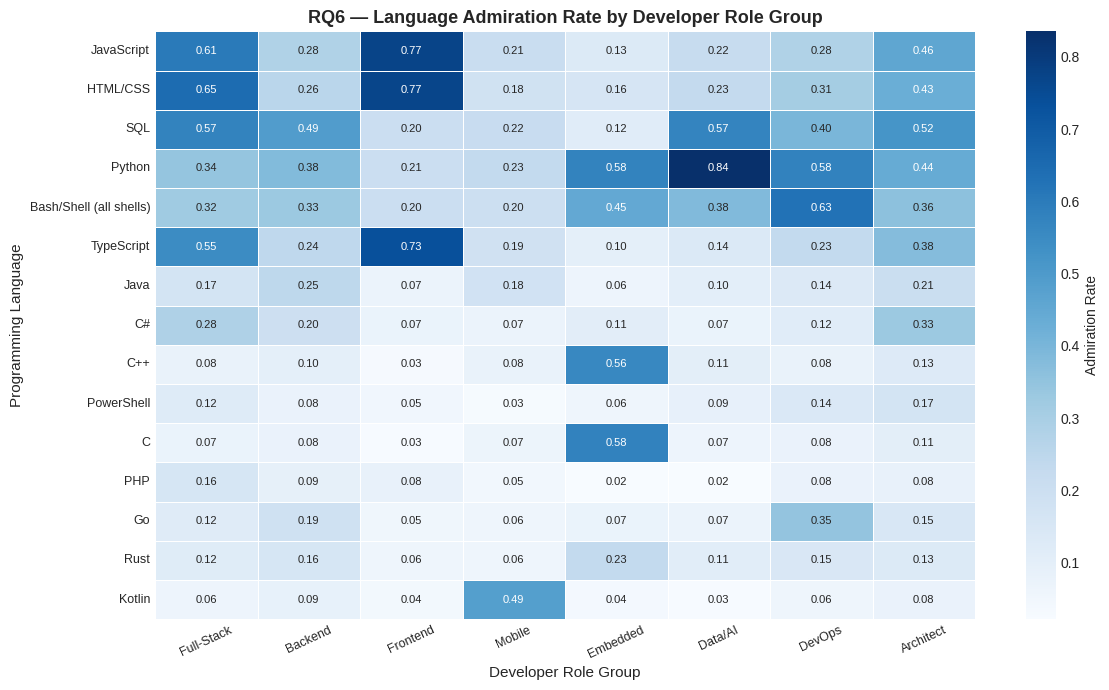

Saved figure: /kaggle/working/rq6_gap_by_devtype_heatmap.pdf


In [98]:
# Heatmap: admiration rate by language × DevType group
if len(gap_dt_df) > 0:
    pivot = gap_dt_df.pivot_table(index='Language', columns='DevType_Group',
                                   values='Admiration_Rate', aggfunc='mean')
    pivot = pivot.reindex(index=top15_langs).dropna(how='all')
    avail_groups = [g for g in DEVTYPE_GROUPS if g in pivot.columns]
    pivot = pivot[avail_groups]

    fig, ax = plt.subplots(figsize=(12, 7))
    sns.heatmap(pivot, ax=ax, annot=True, fmt='.2f', cmap='Blues',
                linewidths=0.4, annot_kws={'size': 8},
                cbar_kws={'label': 'Admiration Rate'})
    ax.set_title('RQ6 — Language Admiration Rate by Developer Role Group', fontsize=13, fontweight='bold')
    ax.set_xlabel('Developer Role Group', fontsize=11)
    ax.set_ylabel('Programming Language', fontsize=11)
    ax.tick_params(axis='x', labelsize=9, rotation=25)
    ax.tick_params(axis='y', labelsize=9, rotation=0)
    plt.tight_layout()
    save_figure(fig, 'rq6_gap_by_devtype_heatmap.pdf')
    plt.show()
else:
    print('Not enough data for DevType heatmap')

In [99]:
save_table(rates_df, 'rq6_technology_rates.csv')
print('Top 10 by admiration-adoption gap:')
rates_df[['Language', 'Adoption_Rate', 'Admiration_Rate', 'Gap_Score', 'Rank_by_Gap']].head(10)

Saved table:  /kaggle/working/rq6_technology_rates.csv
Top 10 by admiration-adoption gap:


,Language,Adoption_Rate,Admiration_Rate,Gap_Score,Rank_by_Gap
0,Gleam,0.01116,0.01066,-0.00049,1
1,Zig,0.02143,0.01855,-0.00287,2
2,Elixir,0.02677,0.02380,-0.00297,3
3,Rust,0.14907,0.14569,-0.00338,4
4,OCaml,0.01160,0.00806,-0.00354,5
5,F#,0.01283,0.00853,-0.00430,6
6,Erlang,0.01470,0.00994,-0.00476,7
7,Lisp,0.02373,0.01855,-0.00518,8
8,Prolog,0.01065,0.00469,-0.00596,9
9,Ada,0.01362,0.00759,-0.00603,10


## 6. Conclusions

In [100]:
top_pos = rates_df[rates_df['Gap_Score'] > 0].head(3)
top_neg = rates_df[rates_df['Gap_Score'] < 0].tail(3)

print('=' * 60)
print('RQ6 CONCLUSION')
print('=' * 60)
print(f'Languages analyzed: {len(rates_df)}')
print(f'Polynomial Degree-2 R²: {r2_poly2:.4f}')
print(f'Polynomial Degree-3 R²: {r2_poly3:.4f}')
print()
print('Highest positive gap (admired more than used):')
for _, row in top_pos.iterrows():
    print(f'  {row["Language"]}: gap={row["Gap_Score"]:+.4f} '
          f'(adoption={row["Adoption_Rate"]:.3f}, admiration={row["Admiration_Rate"]:.3f})')
print()
print('Highest negative gap (used more than admired):')
for _, row in top_neg.iterrows():
    print(f'  {row["Language"]}: gap={row["Gap_Score"]:+.4f} '
          f'(adoption={row["Adoption_Rate"]:.3f}, admiration={row["Admiration_Rate"]:.3f})')
print()
print('Output files saved to /kaggle/working/:')
print('  rq6_admiration_adoption_bubble.pdf')
print('  rq6_gap_score_bar.pdf')
print('  rq6_gap_by_devtype_heatmap.pdf')
print('  rq6_technology_rates.csv')
print('  rq6_gap_by_devtype.csv')

RQ6 CONCLUSION
Languages analyzed: 40
Polynomial Degree-2 R²: 0.9807
Polynomial Degree-3 R²: 0.9846

Highest positive gap (admired more than used):

Highest negative gap (used more than admired):
  Bash/Shell (all shells): gap=-0.1409 (adoption=0.489, admiration=0.349)
  HTML/CSS: gap=-0.1843 (adoption=0.622, admiration=0.438)
  JavaScript: gap=-0.2446 (adoption=0.663, admiration=0.419)

Output files saved to /kaggle/working/:
  rq6_admiration_adoption_bubble.pdf
  rq6_gap_score_bar.pdf
  rq6_gap_by_devtype_heatmap.pdf
  rq6_technology_rates.csv
  rq6_gap_by_devtype.csv
